<a href="https://colab.research.google.com/github/akash-barman007/IDRA_DSAI_Final_Capstone_Project/blob/main/Customer_Churn_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Predicting Customer Churn: A Data-Driven Analysis of Subscription Customer Behaviour**


## 1. Project Overview

## 2. Import Libraries

In [ ]:

# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Dataset


In [ ]:

# Load the Telco Customer Churn dataset

file_path = "/content/P_4_WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


## 4. Dataset Understanding

In [ ]:

# Basic dataset inspection

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
display(df.dtypes)

print("\nBasic Statistical Summary:")
display(df.describe(include="all").T)

Dataset Shape:
(7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Data Types:


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Basic Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Check missing values and duplicate records

print("Missing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Duplicate Rows:
0


## 5. Data Cleaning

In [ ]:

# Detailed data quality check

print("===== MISSING VALUES =====")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n===== DUPLICATE RECORDS =====")
print("Number of duplicate rows:", df.duplicated().sum())

print("\n===== DATA TYPES =====")
display(df.dtypes)

print("\n===== UNIQUE VALUES =====")
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:10])

# Convert TotalCharges to numeric
# Invalid/blank values will become NaN

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values in TotalCharges after conversion:")
print(df["TotalCharges"].isnull().sum())

print("\nData type of TotalCharges:")
print(df["TotalCharges"].dtype)

# Check rows affected by TotalCharges conversion

print("Missing TotalCharges after conversion:")
print(df["TotalCharges"].isnull().sum())

print("\nTotalCharges data type:")
print(df["TotalCharges"].dtype)

# Handle missing TotalCharges values

print("Rows with missing TotalCharges:")
display(df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]])

# Remove rows with missing TotalCharges
df = df.dropna(subset=["TotalCharges"])

print("\nDataset shape after cleaning:")
print(df.shape)

print("\nRemaining missing values:")
print(df.isnull().sum().sum())

# Final dataset validation

print("===== FINAL DATASET CHECK =====")
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())

print("\nFinal data types:")
display(df.dtypes)

===== MISSING VALUES =====
Series([], dtype: int64)

===== DUPLICATE RECORDS =====
Number of duplicate rows: 0

===== DATA TYPES =====


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



===== UNIQUE VALUES =====

customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU']

gender:
['Female' 'Male']

SeniorCitizen:
[0 1]

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

tenure:
[ 1 34  2 45  8 22 10 28 62 13]

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

MonthlyCharges:
[ 29.85  56.95  53.85  42.3   70.7   99.65  89.1   2

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN



Dataset shape after cleaning:
(7032, 21)

Remaining missing values:
0
===== FINAL DATASET CHECK =====
Shape: (7032, 21)
Duplicate rows: 0
Total missing values: 0

Final data types:


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
# ===== OUTLIER CHECK USING IQR METHOD =====

numeric_columns = ["tenure", "MonthlyCharges", "TotalCharges"]

outlier_results = []

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_results.append({
        "Variable": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_results)

display(outlier_summary)

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,tenure,9.0000,55.0000,46.0000,-60.00000,124.00000,0
1,MonthlyCharges,35.5875,89.8625,54.2750,-45.82500,171.27500,0
2,TotalCharges,401.4500,3794.7375,3393.2875,-4688.48125,8884.66875,0


In [ ]:
## 6. Data Preprocessing
# Prepare features and target

# Remove customerID because it is only an identifier
df_model = df.drop(columns=["customerID"]).copy()

# Convert Churn into binary values
df_model["Churn"] = df_model["Churn"].map({"No": 0, "Yes": 1})

print("Features and target prepared successfully.")
print("Shape:", df_model.shape)

print("\nTarget distribution:")
print(df_model["Churn"].value_counts())

Features and target prepared successfully.
Shape: (7032, 20)

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


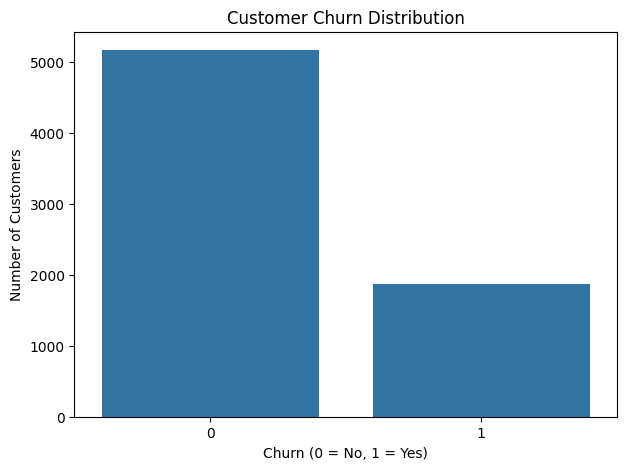

In [ ]:
## 7. Exploratory Data Analysis
# Churn distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df_model, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

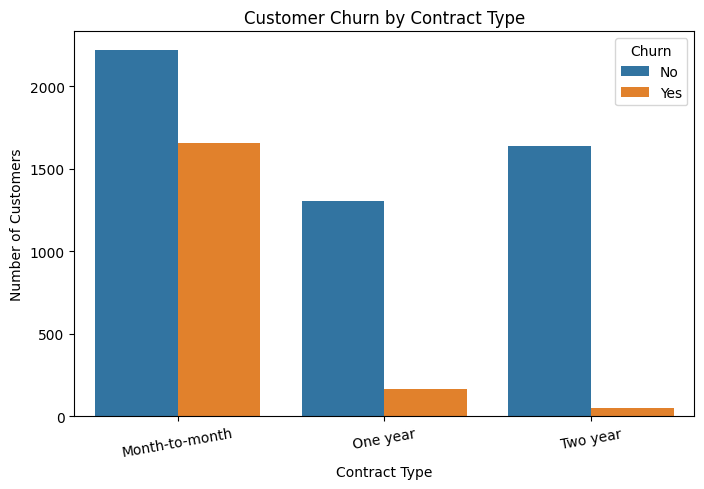

In [ ]:
# Contract type vs customer churn

plt.figure(figsize=(8, 5))

sns.countplot(data=df_model, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["No", "Yes"])

plt.xticks(rotation=10)
plt.show()

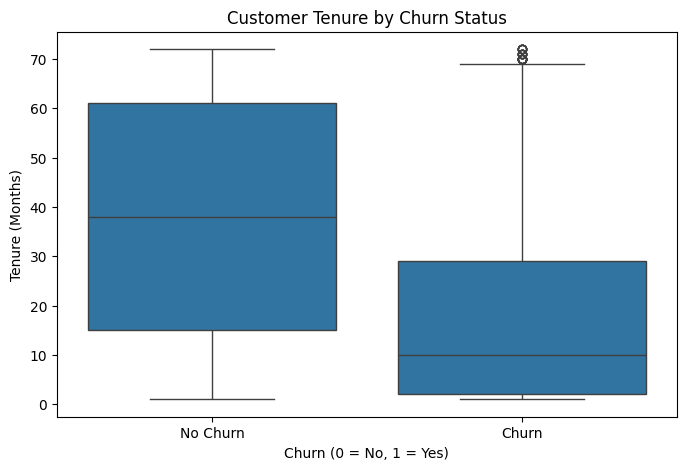

In [ ]:
# Tenure distribution by churn status

plt.figure(figsize=(8, 5))

sns.boxplot(data=df_model, x="Churn", y="tenure")

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (Months)")
plt.xticks([0, 1], ["No Churn", "Churn"])

plt.show()

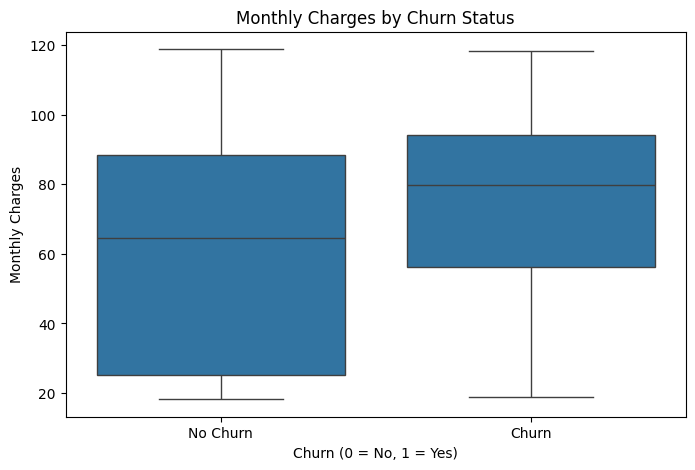

In [ ]:
# Monthly charges by churn status

plt.figure(figsize=(8, 5))

sns.boxplot(data=df_model, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")
plt.xticks([0, 1], ["No Churn", "Churn"])

plt.show()

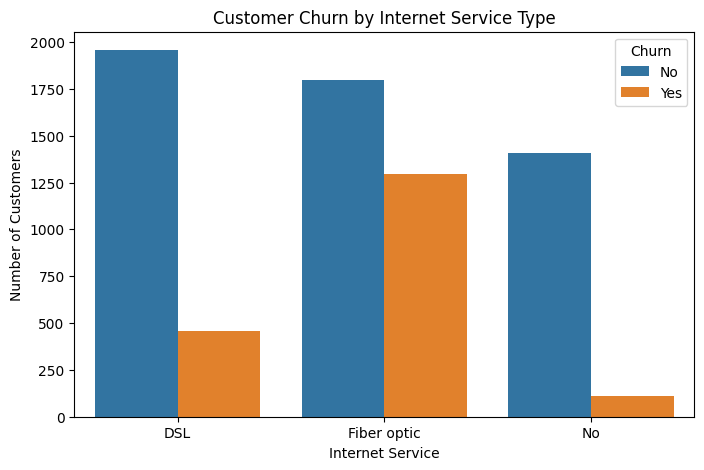

In [ ]:
# Internet service type vs customer churn

plt.figure(figsize=(8, 5))

sns.countplot(data=df_model, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["No", "Yes"])

plt.show()

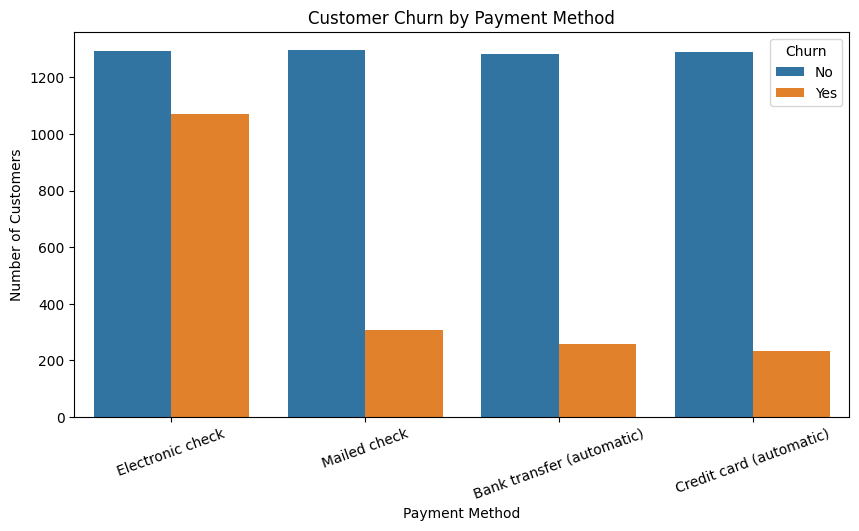

In [ ]:
# Payment method vs customer churn

plt.figure(figsize=(10, 5))

sns.countplot(data=df_model, x="PaymentMethod", hue="Churn")

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["No", "Yes"])

plt.xticks(rotation=20)
plt.show()

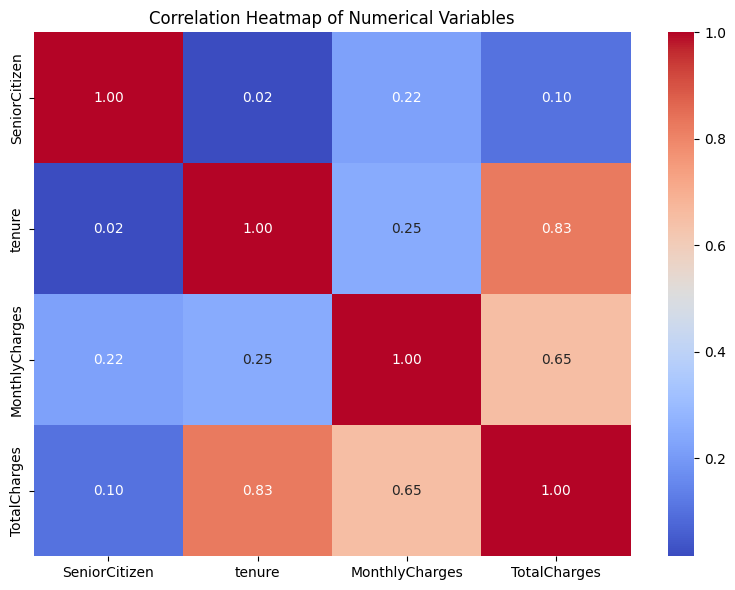

In [ ]:
# ===== CORRELATION ANALYSIS =====

correlation_data = df[[
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

In [ ]:
## 8. Statistical Analysis
# Basic statistical analysis of customer churn

churn_rate = df_model["Churn"].mean() * 100

print("===== CHURN STATISTICS =====")
print(f"Total customers: {len(df_model)}")
print(f"Customers who did not churn: {(df_model['Churn'] == 0).sum()}")
print(f"Customers who churned: {(df_model['Churn'] == 1).sum()}")
print(f"Overall churn rate: {churn_rate:.2f}%")

===== CHURN STATISTICS =====
Total customers: 7032
Customers who did not churn: 5163
Customers who churned: 1869
Overall churn rate: 26.58%


In [ ]:
# Compare numerical features by churn status

numerical_summary = df_model.groupby("Churn")[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]].agg(["mean", "median"])

display(numerical_summary)

tenure        MonthlyCharges        TotalCharges         
            mean median           mean median         mean   median
Churn                                                              
0      37.650010   38.0      61.307408  64.45  2555.344141  1683.60
1      17.979133   10.0      74.441332  79.65  1531.796094   703.55

In [ ]:
from scipy.stats import mannwhitneyu

# Statistical significance tests

churned = df_model[df_model["Churn"] == 1]
not_churned = df_model[df_model["Churn"] == 0]

# Tenure test
tenure_stat, tenure_p = mannwhitneyu(
    churned["tenure"],
    not_churned["tenure"],
    alternative="two-sided"
)

# Monthly Charges test
charges_stat, charges_p = mannwhitneyu(
    churned["MonthlyCharges"],
    not_churned["MonthlyCharges"],
    alternative="two-sided"
)

print("===== MANN-WHITNEY U TEST =====")

print(f"Tenure: U = {tenure_stat:.2f}, p-value = {tenure_p:.6f}")
print(f"Monthly Charges: U = {charges_stat:.2f}, p-value = {charges_p:.6f}")

===== MANN-WHITNEY U TEST =====
Tenure: U = 2494979.00, p-value = 0.000000
Monthly Charges: U = 5986148.50, p-value = 0.000000


In [ ]:
# Categorical feature statistical analysis

from scipy.stats import chi2_contingency

# Contract vs Churn
contract_table = pd.crosstab(
    df_model["Contract"],
    df_model["Churn"]
)

contract_chi2, contract_p, contract_dof, contract_expected = chi2_contingency(
    contract_table
)

# Internet Service vs Churn
internet_table = pd.crosstab(
    df_model["InternetService"],
    df_model["Churn"]
)

internet_chi2, internet_p, internet_dof, internet_expected = chi2_contingency(
    internet_table
)

print("===== CHI-SQUARE TESTS =====")

print("\nContract vs Churn")
display(contract_table)
print(f"Chi-square statistic: {contract_chi2:.2f}")
print(f"Degrees of freedom: {contract_dof}")
print(f"p-value: {contract_p:.6f}")

print("\nInternet Service vs Churn")
display(internet_table)
print(f"Chi-square statistic: {internet_chi2:.2f}")
print(f"Degrees of freedom: {internet_dof}")
print(f"p-value: {internet_p:.6f}")

===== CHI-SQUARE TESTS =====

Contract vs Churn


Churn,0,1
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


Chi-square statistic: 1179.55
Degrees of freedom: 2
p-value: 0.000000

Internet Service vs Churn


Churn,0,1
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


Chi-square statistic: 728.70
Degrees of freedom: 2
p-value: 0.000000


In [ ]:
## 9. Feature Engineering

df_model_fe = df_model.copy()

# Average monthly spending over the customer's tenure
df_model_fe["AvgMonthlySpend"] = (
    df_model_fe["TotalCharges"] /
    df_model_fe["tenure"].replace(0, np.nan)
)

# Replace undefined values for zero-tenure customers
df_model_fe["AvgMonthlySpend"] = df_model_fe["AvgMonthlySpend"].fillna(
    df_model_fe["MonthlyCharges"]
)

print("Feature engineering completed.")
print("\nNew feature: AvgMonthlySpend")

display(
    df_model_fe[
        ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend"]
    ].head()
)

Feature engineering completed.

New feature: AvgMonthlySpend


,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000


In [ ]:
# Validate engineered feature

print("Original features:", df_model.shape[1] - 1)
print("Features after engineering:", df_model_fe.shape[1] - 1)

print("\nMissing values in engineered dataset:")
print(df_model_fe.isnull().sum().sum())

print("\nEngineered dataset shape:")
print(df_model_fe.shape)

Original features: 19
Features after engineering: 20

Missing values in engineered dataset:
0

Engineered dataset shape:
(7032, 21)


In [ ]:
# Prepare features and target for machine learning

X = df_model_fe.drop(columns=["Churn"])
y = df_model_fe["Churn"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (5625, 20)
Testing set shape: (1407, 20)

Training target distribution:
Churn
0    4130
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1033
1     374
Name: count, dtype: int64


In [ ]:
# Identify numerical and categorical features

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numerical features: 5
Number of categorical features: 15


In [ ]:
# Create preprocessing pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")
print("Numerical features will be standardized.")
print("Categorical features will be one-hot encoded.")

Preprocessing pipeline created successfully.
Numerical features will be standardized.
Categorical features will be one-hot encoded.


In [ ]:
# Apply preprocessing to training and testing data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing applied successfully.")
print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Preprocessing applied successfully.
Processed training data shape: (5625, 46)
Processed testing data shape: (1407, 46)


In [ ]:
## 10. Machine Learning
# Train Logistic Regression model

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# Evaluate Logistic Regression model

y_train_pred_lr = logistic_model.predict(X_train_processed)
y_test_pred_lr = logistic_model.predict(X_test_processed)

print("===== LOGISTIC REGRESSION RESULTS =====")

print("\nTraining Performance:")
print(f"Accuracy : {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred_lr):.4f}")
print(f"F1-score : {f1_score(y_train, y_train_pred_lr):.4f}")

print("\nTesting Performance:")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred_lr):.4f}")
print(f"F1-score : {f1_score(y_test, y_test_pred_lr):.4f}")

===== LOGISTIC REGRESSION RESULTS =====

Training Performance:
Accuracy : 0.8041
Precision: 0.6568
Recall   : 0.5505
F1-score : 0.5990

Testing Performance:
Accuracy : 0.8038
Precision: 0.6485
Recall   : 0.5722
F1-score : 0.6080


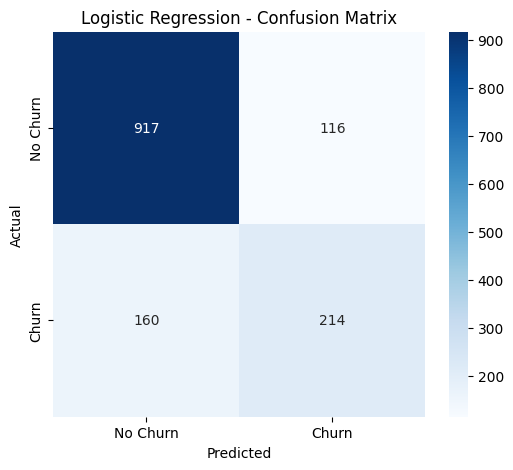

In [ ]:
# Confusion Matrix - Logistic Regression

cm_lr = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Train Decision Tree model

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree_model.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [ ]:
# Evaluate Decision Tree model

y_train_pred_dt = decision_tree_model.predict(X_train_processed)
y_test_pred_dt = decision_tree_model.predict(X_test_processed)

print("===== DECISION TREE RESULTS =====")

print("\nTraining Performance:")
print(f"Accuracy : {accuracy_score(y_train, y_train_pred_dt):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred_dt):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred_dt):.4f}")
print(f"F1-score : {f1_score(y_train, y_train_pred_dt):.4f}")

print("\nTesting Performance:")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_dt):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred_dt):.4f}")
print(f"F1-score : {f1_score(y_test, y_test_pred_dt):.4f}")

===== DECISION TREE RESULTS =====

Training Performance:
Accuracy : 0.8007
Precision: 0.6173
Recall   : 0.6582
F1-score : 0.6371

Testing Performance:
Accuracy : 0.7839
Precision: 0.5862
Recall   : 0.6364
F1-score : 0.6103


**11. Model Evaluation**

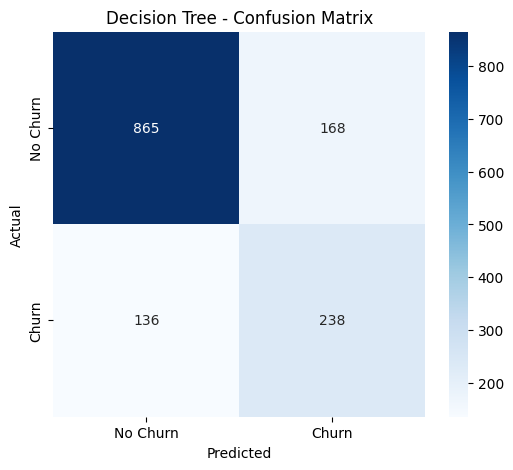

In [ ]:
# Confusion Matrix - Decision Tree

cm_dt = confusion_matrix(y_test, y_test_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Compare Logistic Regression and Decision Tree

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_test_pred_lr),
        accuracy_score(y_test, y_test_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_test_pred_lr),
        precision_score(y_test, y_test_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_test_pred_lr),
        recall_score(y_test, y_test_pred_dt)
    ],
    "F1-Score": [
        f1_score(y_test, y_test_pred_lr),
        f1_score(y_test, y_test_pred_dt)
    ]
})

print("===== MODEL COMPARISON =====")
display(model_comparison.round(4))

===== MODEL COMPARISON =====


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8038,0.6485,0.5722,0.6080
1,Decision Tree,0.7839,0.5862,0.6364,0.6103


In [ ]:
# Check training vs testing performance

overfit_check = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Training Accuracy": [
        accuracy_score(y_train, y_train_pred_lr),
        accuracy_score(y_train, y_train_pred_dt)
    ],
    "Testing Accuracy": [
        accuracy_score(y_test, y_test_pred_lr),
        accuracy_score(y_test, y_test_pred_dt)
    ]
})

overfit_check["Accuracy Gap"] = (
    overfit_check["Training Accuracy"] -
    overfit_check["Testing Accuracy"]
)

print("===== TRAINING vs TESTING PERFORMANCE =====")
display(overfit_check.round(4))

===== TRAINING vs TESTING PERFORMANCE =====


,Model,Training Accuracy,Testing Accuracy,Accuracy Gap
0,Logistic Regression,0.8041,0.8038,0.0003
1,Decision Tree,0.8007,0.7839,0.0168


**12. Results and Findings**

### Model Performance Summary

The two classification models were evaluated using accuracy, precision, recall, and F1-score on the testing dataset.

Logistic Regression achieved a testing accuracy of 80.38%, with a precision of 64.85%, recall of 57.22%, and F1-score of 60.80%.

Decision Tree achieved a testing accuracy of 78.39%, with a precision of 58.62%, recall of 63.64%, and F1-score of 61.03%.

The training and testing accuracy comparison showed a very small accuracy gap for Logistic Regression (0.0003) and a modest gap for the Decision Tree (0.0168), indicating no substantial overfitting based on this measure.

### Key Findings from Exploratory and Statistical Analysis

The dataset contains 7,032 customers after data cleaning, with 1,869 customers classified as churned and 5,163 classified as non-churned. The overall churn rate is 26.58%.

The contract analysis shows that customers with month-to-month contracts have substantially more churn cases than customers with one-year or two-year contracts. This indicates a strong association between contract type and churn status.

The tenure analysis shows that churned customers generally have lower tenure than customers who did not churn. The median tenure was 10 months for churned customers compared with 38 months for non-churned customers.

Monthly charges were also higher on average among churned customers. The mean monthly charge was approximately 74.44 for churned customers compared with 61.31 for non-churned customers.

The statistical analysis using the Mann-Whitney U test found statistically significant differences between churned and non-churned customers for both tenure and monthly charges (p < 0.001).

The chi-square tests also indicated statistically significant associations between churn status and contract type, as well as between churn status and internet service type (p < 0.001).

These findings identify contract type, customer tenure, monthly charges, and internet service as important variables to consider when analysing customer churn. However, the observed associations do not by themselves establish causal relationships.


## 13. Conclusion



This project analysed customer subscription data to understand patterns associated with customer churn and developed machine learning models for churn classification.

The analysis found meaningful differences between churned and non-churned customers in terms of tenure and monthly charges. Contract type and internet service type also showed statistically significant associations with churn status.

Two classification models, Logistic Regression and Decision Tree, were developed and evaluated using accuracy, precision, recall, and F1-score. Both models achieved approximately 78–80% testing accuracy, while their precision, recall, and F1-score values provided additional information about their ability to identify churned customers.

The results demonstrate that customer churn can be analysed using a combination of exploratory data analysis, statistical testing, feature engineering, and machine learning. The findings can support data-driven investigation of customer behaviour and help identify customer characteristics associated with higher churn risk.